In [1]:
!pip install sentence-transformers


Thứ tự   | Lớp ID   | Số lượng giữ lại
----------------------------------------
0        | 10       | 999
1        | 15       | 565
2        | 8        | 327
3        | 9        | 197
4        | 11       | 126
5        | 13       | 87
6        | 7        | 65
7        | 5        | 54
8        | 14       | 47
9        | 2        | 44
10       | 12       | 42
11       | 3        | 41
12       | 6        | 40
13       | 1        | 40
14       | 4        | 40
15       | 17       | 40
16       | 16       | 40
17       | 0        | 40
18       | 18       | 40
19       | 19       | 40


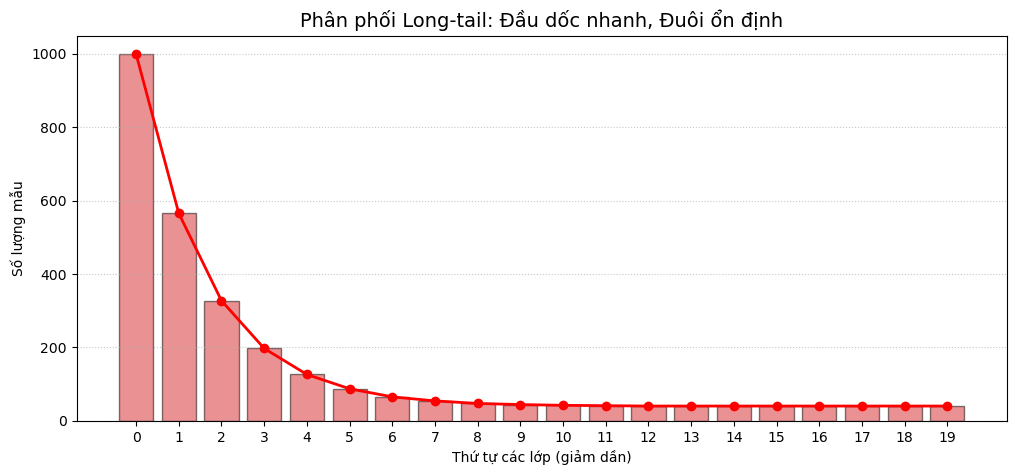

Tổng số mẫu: 2914
Entropy: 2.2340


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def create_custom_longtail(X, Y, min_samples=50, steepness=0.6):
    """
    X, Y: Dữ liệu và nhãn gốc
    min_samples: Số lượng mẫu tối thiểu cho lớp nhỏ nhất (để đuôi không quá nhỏ)
    steepness: Độ dốc ban đầu (càng cao rớt càng nhanh)
    """
    unique_classes = np.unique(Y)
    num_classes = len(unique_classes)
    
    X_lt, Y_lt = [], []
    
    # Sắp xếp các class theo số lượng gốc giảm dần
    counts_orig = np.array([len(np.where(Y == c)[0]) for c in unique_classes])
    sorted_classes = unique_classes[np.argsort(counts_orig)[::-1]]

    print(f"{'Thứ tự':<8} | {'Lớp ID':<8} | {'Số lượng giữ lại'}")
    print("-" * 40)

    for i, cls in enumerate(sorted_classes):
        idx = np.where(Y == cls)[0]
        np.random.shuffle(idx)
        
        n_max = len(idx) # Số lượng mẫu tối đa lớp này đang có (thường ~800-900)
        
        # CÔNG THỨC MỚI: Exponential Decay + Offset
        # n_i = (N_max - N_min) * exp(-steepness * i) + N_min
        # i=0 -> n = N_max
        # i lớn -> n tiến về N_min
        decay_factor = np.exp(-steepness * i)
        num_to_keep = int((n_max - min_samples) * decay_factor + min_samples)
        
        # Đảm bảo không lấy quá số lượng ảnh thực tế đang có
        final_num = min(len(idx), num_to_keep)

        print(f"{i:<8} | {cls:<8} | {final_num}")
        
        X_lt.extend(X[idx[:final_num]])
        Y_lt.extend([cls] * final_num)
        
    return X_lt, np.array(Y_lt)

# THỰC THI
# steepness=0.6: rớt rất nhanh ở 4 lớp đầu
# min_samples=40: lớp ít nhất sẽ có khoảng 40-50 mẫu (đủ để HK-means thể hiện)
X_lt_text, Y_lt_text = create_custom_longtail(X_text, Y_labels, min_samples=40, steepness=0.6)

# --- VẼ BIỂU ĐỒ KIỂM TRA ---
classes, counts = np.unique(Y_lt_text, return_counts=True)
# Sắp xếp lại counts để vẽ histogram giảm dần
sorted_counts = np.sort(counts)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(20), sorted_counts, color='tab:red', alpha=0.5, edgecolor='black')
plt.plot(range(20), sorted_counts, color='red', marker='o', linewidth=2)

plt.title('Phân phối Long-tail: Đầu dốc nhanh, Đuôi ổn định', fontsize=14)
plt.xlabel('Thứ tự các lớp (giảm dần)')
plt.ylabel('Số lượng mẫu')
plt.xticks(range(20))
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

print(f"Tổng số mẫu: {len(Y_lt_text)}")
print(f"Entropy: {entropy(sorted_counts/len(Y_lt_text)):.4f}")

# long tail nhiều hơn

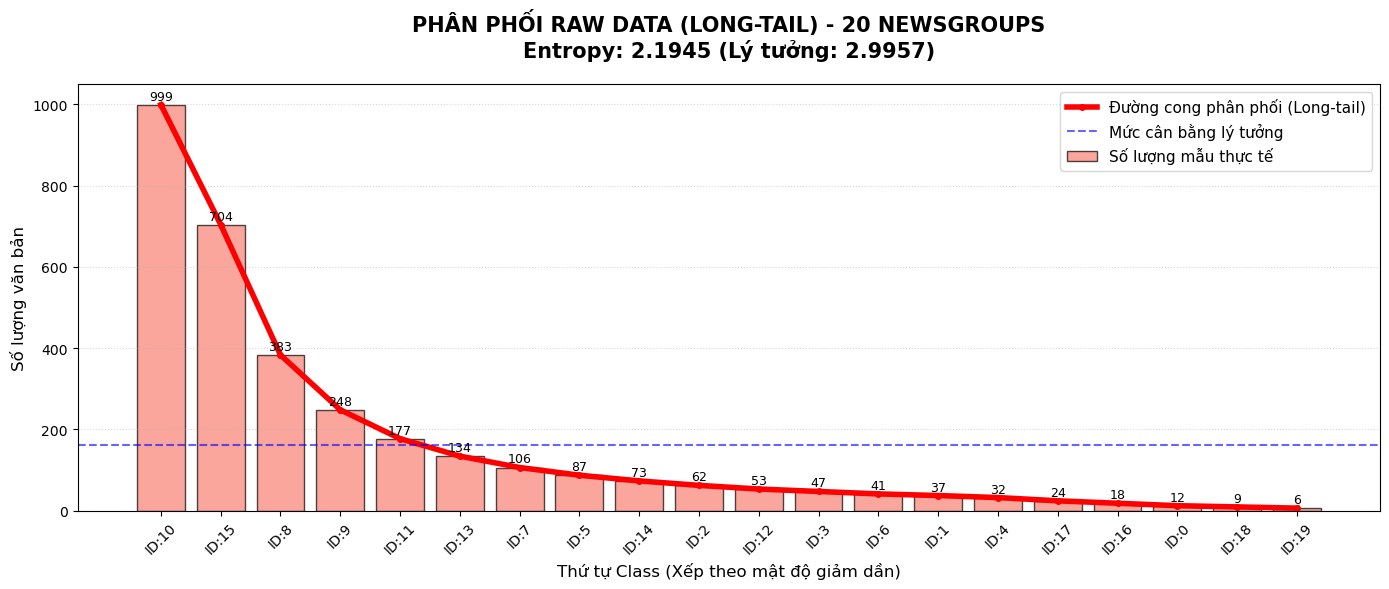

--- THỐNG KÊ CHI TIẾT ---
Lớp nhiều nhất (Head): ID 10 với 999 mẫu
Lớp ít nhất (Tail):   ID 19 với 6 mẫu
Tỷ lệ mất cân bằng:    166.50 lần


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 1. Lấy danh sách class và số lượng mẫu tương ứng
classes_raw, counts_raw = np.unique(Y_lt_text, return_counts=True)

# 2. SẮP XẾP: Tìm index để sắp xếp counts giảm dần
sort_idx = np.argsort(counts_raw)[::-1]
sorted_classes = classes_raw[sort_idx]
sorted_counts = counts_raw[sort_idx]

# 3. Tính toán Entropy (giá trị không đổi khi sắp xếp, nhưng dùng để hiển thị)
current_entropy = entropy(sorted_counts / len(Y_lt_text))
ideal_entropy = np.log(20)

# 4. VẼ BIỂU ĐỒ
plt.figure(figsize=(14, 6))

# Vẽ các thanh Histogram đã sắp xếp
bars = plt.bar(range(20), sorted_counts, color='salmon', alpha=0.7, edgecolor='black', label='Số lượng mẫu thực tế')

# Vẽ đường cong màu đỏ (Smooth curve) để minh họa hàm Power Law như trong báo
plt.plot(range(20), sorted_counts, color='red', linewidth=4, marker='o', markersize=4, label='Đường cong phân phối (Long-tail)')

# 5. Định dạng biểu đồ
plt.title(f'PHÂN PHỐI RAW DATA (LONG-TAIL) - 20 NEWSGROUPS\nEntropy: {current_entropy:.4f} (Lý tưởng: {ideal_entropy:.4f})', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Thứ tự Class (Xếp theo mật độ giảm dần)', fontsize=12)
plt.ylabel('Số lượng văn bản', fontsize=12)

# Hiển thị Class ID gốc dưới mỗi thanh để biết class nào là "Head", class nào là "Tail"
plt.xticks(range(20), [f"ID:{c}" for c in sorted_classes], rotation=45)

# Thêm đường trung bình lý tưởng để thấy độ lệch
plt.axhline(y=len(Y_lt_text)/20, color='blue', linestyle='--', alpha=0.6, label='Mức cân bằng lý tưởng')

plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Hiển thị số lượng cụ thể trên đầu mỗi cột (tùy chọn, nếu muốn rõ ràng)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

print(f"--- THỐNG KÊ CHI TIẾT ---")
print(f"Lớp nhiều nhất (Head): ID {sorted_classes[0]} với {sorted_counts[0]} mẫu")
print(f"Lớp ít nhất (Tail):   ID {sorted_classes[-1]} với {sorted_counts[-1]} mẫu")
print(f"Tỷ lệ mất cân bằng:    {sorted_counts[0]/sorted_counts[-1]:.2f} lần")

In [29]:
from sentence_transformers import SentenceTransformer

print("Đang trích xuất đặc trưng văn bản (Sentence-BERT)...")
# all-MiniLM-L6-v2 cho kết quả 384 chiều, rất nhanh và mạnh
model = SentenceTransformer('all-MiniLM-L6-v2') 

X_features_text = model.encode(X_lt_text, batch_size=64, show_progress_bar=True)

# Lưu lại để chạy Grid Testing
os.makedirs('../data/text_processed', exist_ok=True)
np.save('../data/text_processed/X_features_text_exp.npy', X_features_text)
np.save('../data/text_processed/Y_longtail_text_exp.npy', Y_lt_text)

print("Xong! Dữ liệu đã sẵn sàng để Grid Testing.")

Đang trích xuất đặc trưng văn bản (Sentence-BERT)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Xong! Dữ liệu đã sẵn sàng để Grid Testing.


In [31]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
import sys
import os
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

sys.path.append(os.path.abspath(os.path.join('..')))
from src.model_copy import hierarchical_kmeans_resampling

X_text_norm = normalize(X_features_text)
# Cấu hình 10 cases thử nghiệm
test_configs = [
    {"T": 2, "m": 5,  "k_list": [600, 300]},
    {"T": 2, "m": 10, "k_list": [600, 300]},
    {"T": 2, "m": 20, "k_list": [600, 300]}, # Test m lớn
    {"T": 3, "m": 5,  "k_list": [800, 500, 300]},
    {"T": 3, "m": 10, "k_list": [800, 500, 300]},
    {"T": 3, "m": 20, "k_list": [800, 500, 300]},
    {"T": 3, "m": 10, "k_list": [1000, 600, 400]}, # Test k_final lớn hơn
    {"T": 4, "m": 5,  "k_list": [1200, 800, 500, 300]},
    {"T": 4, "m": 10, "k_list": [1200, 800, 500, 300]},
    {"T": 4, "m": 15, "k_list": [1200, 800, 500, 300]}, # Test T cực sâu
]

results = []

for config in test_configs:
    T, m, k_list = config["T"], config["m"], config["k_list"]
    k_final = k_list[-1]
    
    print(f"Testing Case: T={T}, m={m}, k_final={k_final}...")
    
    t0 = time.time()
    
    # 1. Chạy HK-means (Hàm của bạn)
    centroids = hierarchical_kmeans_resampling(X_text_norm, k_list, T, m, num_init=1)
    
    # 2. Gán nhãn
    km = KMeans(n_clusters=k_final, init=centroids, n_init=1).fit(X_text_norm)
    labels = km.labels_
    
    # 3. Nhặt ảnh (Logic avg // 2 của bạn)
    avg_per_cluster = len(X_text_norm) // k_final
    target = max(1, avg_per_cluster // 2)
    
    curated_idx = []
    for i in range(k_final):
        cluster_idx = np.where(labels == i)[0]
        if len(cluster_idx) == 0: continue
        d = np.linalg.norm(X_text_norm[cluster_idx] - centroids[i], axis=1)
        curated_idx.extend(cluster_idx[np.argsort(d)[:min(len(cluster_idx), target)]])
    
    t1 = time.time()
    
    # 4. Đo đạc
    res_entropy = entropy(np.unique(Y_lt_text[curated_idx], return_counts=True)[1] / len(curated_idx))
    
    results.append({
        "Config": f"T{T}m{m}k{k_final}",
        "Time": t1 - t0,
        "Entropy": res_entropy,
        "N": len(curated_idx)
    })

df = pd.DataFrame(results)

Testing Case: T=2, m=5, k_final=300...
new hkm
--- Level 1/2 (k=600, r_t tự động=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 2/2 (k=300, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Testing Case: T=2, m=10, k_final=300...
new hkm
--- Level 1/2 (k=600, r_t tự động=2) ---


...

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/4 (k=500, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 4/4 (k=300, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

# long tail nhiều

C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_12956\381748895.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Config'], rotation=45)


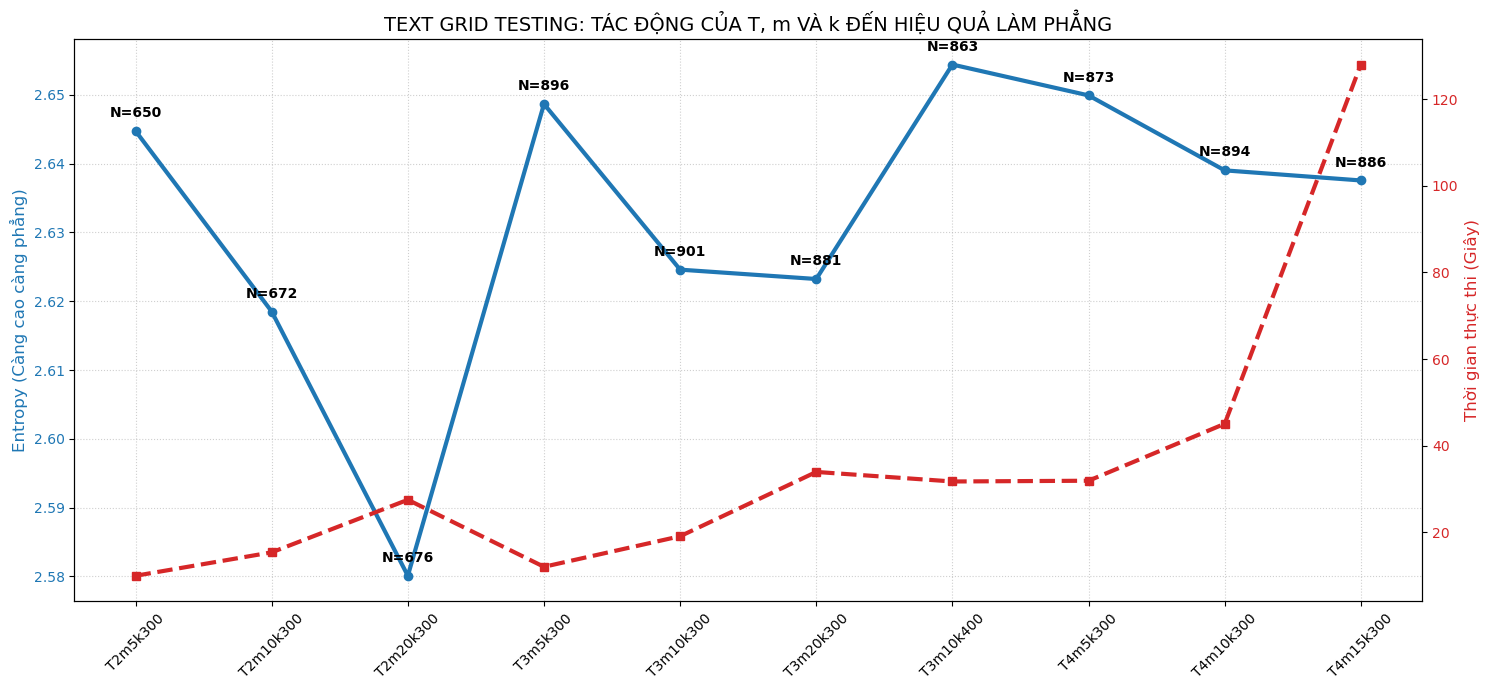

In [32]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Đường Entropy
ax1.plot(df['Config'], df['Entropy'], color='tab:blue', marker='o', linewidth=3, label='Entropy')
ax1.set_ylabel('Entropy (Càng cao càng phẳng)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Đường Thời gian
ax2 = ax1.twinx()
ax2.plot(df['Config'], df['Time'], color='tab:red', marker='s', linestyle='--', linewidth=3, label='Thời gian')
ax2.set_ylabel('Thời gian thực thi (Giây)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Chú thích số lượng mẫu N ngay trên biểu đồ
for i in range(len(df)):
    ax1.annotate(f"N={df['N'][i]}", (df['Config'][i], df['Entropy'][i]), 
                 xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.title('TEXT GRID TESTING: TÁC ĐỘNG CỦA T, m VÀ k ĐẾN HIỆU QUẢ LÀM PHẲNG', fontsize=14)
ax1.set_xticklabels(df['Config'], rotation=45)
ax1.grid(axis='both', linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

# long tail ít

C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_25760\381748895.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df['Config'], rotation=45)


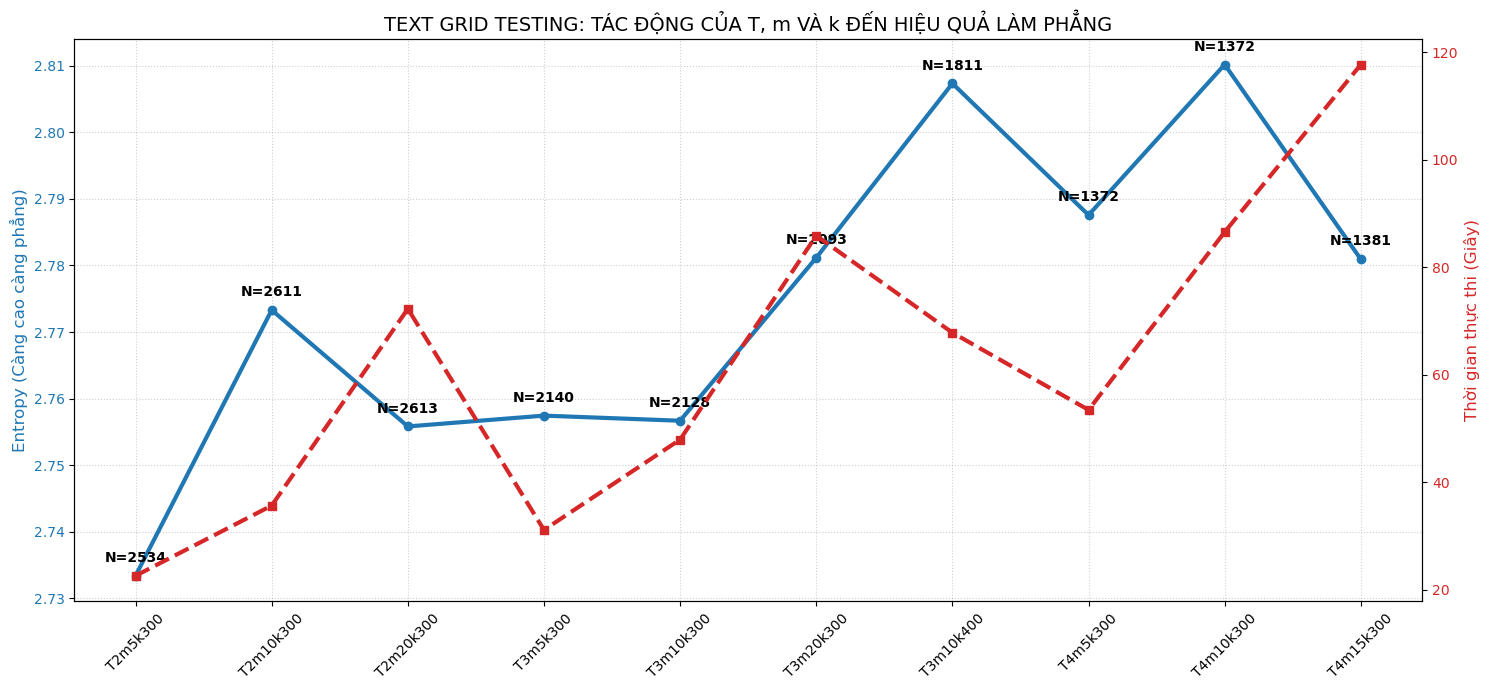

In [10]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Đường Entropy
ax1.plot(df['Config'], df['Entropy'], color='tab:blue', marker='o', linewidth=3, label='Entropy')
ax1.set_ylabel('Entropy (Càng cao càng phẳng)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Đường Thời gian
ax2 = ax1.twinx()
ax2.plot(df['Config'], df['Time'], color='tab:red', marker='s', linestyle='--', linewidth=3, label='Thời gian')
ax2.set_ylabel('Thời gian thực thi (Giây)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Chú thích số lượng mẫu N ngay trên biểu đồ
for i in range(len(df)):
    ax1.annotate(f"N={df['N'][i]}", (df['Config'][i], df['Entropy'][i]), 
                 xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.title('TEXT GRID TESTING: TÁC ĐỘNG CỦA T, m VÀ k ĐẾN HIỆU QUẢ LÀM PHẲNG', fontsize=14)
ax1.set_xticklabels(df['Config'], rotation=45)
ax1.grid(axis='both', linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

--- PHÂN TÍCH ĐỘ CÂN BẰNG BAN ĐẦU (LONG-TAIL) ---
Số lượng class: 20
Entropy thực tế (Long-tail): 2.7832
Entropy lý tưởng (Max):      2.9957
Hiệu suất cân bằng ban đầu:  92.91%
Ngưỡng Entropy 'ổn' (>95%):  2.8459


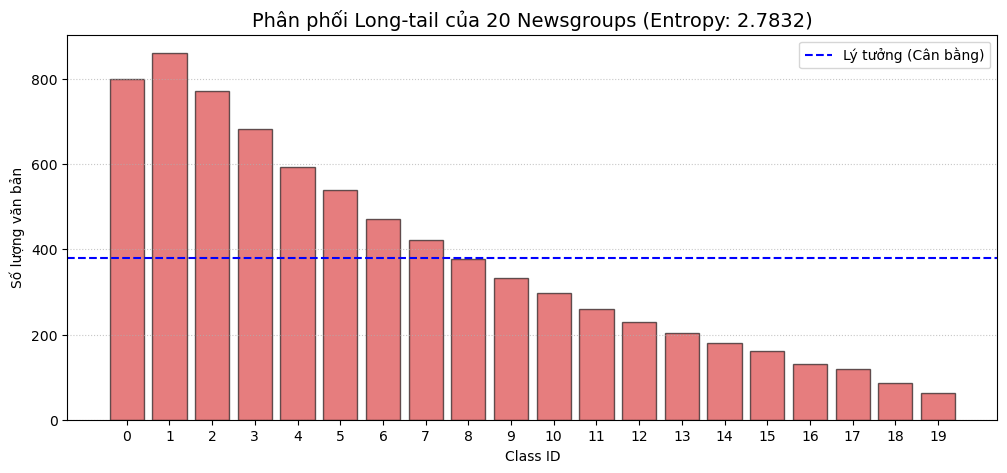

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 1. Tính toán phân phối các lớp
classes, counts = np.unique(Y_lt_text, return_counts=True)
proportions = counts / len(Y_lt_text)

# 2. Tính Entropy thực tế của tập Long-tail
initial_entropy = entropy(proportions)

# 3. Tính Entropy lý tưởng (Cân bằng tuyệt đối)
# Công thức: H_max = ln(C) với C là số lượng class
num_classes = 20
ideal_entropy = np.log(num_classes)

# 4. Ngưỡng đánh giá (Heuristic)
# Entropy ổn định: Thường đạt > 90% Entropy lý tưởng là rất tốt
stable_threshold = ideal_entropy * 0.95 

print(f"--- PHÂN TÍCH ĐỘ CÂN BẰNG BAN ĐẦU (LONG-TAIL) ---")
print(f"Số lượng class: {num_classes}")
print(f"Entropy thực tế (Long-tail): {initial_entropy:.4f}")
print(f"Entropy lý tưởng (Max):      {ideal_entropy:.4f}")
print(f"Hiệu suất cân bằng ban đầu:  {(initial_entropy/ideal_entropy)*100:.2f}%")
print(f"Ngưỡng Entropy 'ổn' (>95%):  {stable_threshold:.4f}")

# 5. Vẽ biểu đồ Histogram phân phối Long-tail
plt.figure(figsize=(12, 5))
plt.bar(classes, counts, color='tab:red', alpha=0.6, edgecolor='black')
plt.axhline(y=len(Y_lt_text)/num_classes, color='blue', linestyle='--', label='Lý tưởng (Cân bằng)')
plt.title(f'Phân phối Long-tail của 20 Newsgroups (Entropy: {initial_entropy:.4f})', fontsize=14)
plt.xlabel('Class ID')
plt.ylabel('Số lượng văn bản')
plt.xticks(range(20))
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Cấu hình 10 cases thử nghiệm
test_configs = [
    {"T": 2, "m": 5,  "k_list": [600, 300]},
    {"T": 2, "m": 10, "k_list": [600, 300]},
    {"T": 2, "m": 20, "k_list": [600, 300]}, # Test m lớn
    {"T": 3, "m": 5,  "k_list": [800, 500, 300]},
    {"T": 3, "m": 10, "k_list": [800, 500, 300]},
    {"T": 3, "m": 20, "k_list": [800, 500, 300]},
    {"T": 3, "m": 10, "k_list": [1000, 600, 400]}, # Test k_final lớn hơn
    {"T": 4, "m": 5,  "k_list": [1200, 800, 500, 300]},
    {"T": 4, "m": 10, "k_list": [1200, 800, 500, 300]},
    {"T": 4, "m": 15, "k_list": [1200, 800, 500, 300]}, # Test T cực sâu
]

results = []

for config in test_configs:
    T, m, k_list = config["T"], config["m"], config["k_list"]
    k_final = k_list[-1]
    
    print(f"Testing Case: T={T}, m={m}, k_final={k_final}...")
    
    t0 = time.time()
    
    # 1. Chạy HK-means (Hàm của bạn)
    centroids = hierarchical_kmeans_resampling(X_text_norm, k_list, T, m, num_init=5)
    
    # 2. Gán nhãn
    km = KMeans(n_clusters=k_final, init=centroids, n_init=5).fit(X_text_norm)
    labels = km.labels_
    
    # 3. Nhặt ảnh (Logic avg // 2 của bạn)
    avg_per_cluster = len(X_text_norm) // k_final
    target = max(1, avg_per_cluster // 2)
    
    curated_idx = []
    for i in range(k_final):
        cluster_idx = np.where(labels == i)[0]
        if len(cluster_idx) == 0: continue
        d = np.linalg.norm(X_text_norm[cluster_idx] - centroids[i], axis=1)
        curated_idx.extend(cluster_idx[np.argsort(d)[:min(len(cluster_idx), target)]])
    
    t1 = time.time()
    
    # 4. Đo đạc
    res_entropy = entropy(np.unique(Y_text_lt[curated_idx], return_counts=True)[1] / len(curated_idx))
    
    results.append({
        "Config": f"T{T}m{m}k{k_final}",
        "Time": t1 - t0,
        "Entropy": res_entropy,
        "N": len(curated_idx)
    })

df = pd.DataFrame(results)

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Đường Entropy
ax1.plot(df['Config'], df['Entropy'], color='tab:blue', marker='o', linewidth=3, label='Entropy')
ax1.set_ylabel('Entropy (Càng cao càng phẳng)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Đường Thời gian
ax2 = ax1.twinx()
ax2.plot(df['Config'], df['Time'], color='tab:red', marker='s', linestyle='--', linewidth=3, label='Thời gian')
ax2.set_ylabel('Thời gian thực thi (Giây)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Chú thích số lượng mẫu N ngay trên biểu đồ
for i in range(len(df)):
    ax1.annotate(f"N={df['N'][i]}", (df['Config'][i], df['Entropy'][i]), 
                 xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.title('TEXT GRID TESTING: TÁC ĐỘNG CỦA T, m VÀ k ĐẾN HIỆU QUẢ LÀM PHẲNG', fontsize=14)
ax1.set_xticklabels(df['Config'], rotation=45)
ax1.grid(axis='both', linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

new hkm
--- Level 1/3 (k=1000, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 2/3 (k=600, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 (k=400, r_t tự động=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Đang huấn luyện trên tập Long-tail (N=2914)...
Đang huấn luyện trên tập Curated (N=1221)...

--- BẢNG SO SÁNH HIỆU NĂNG ---
                      Metric  Long-tail (Raw)  Curated (HK-means)
0                   Accuracy         0.890223            0.855918
1             Macro F1-Score         0.749490            0.645568
2  Dung lượng tập huấn luyện      2914.000000         1221.000000


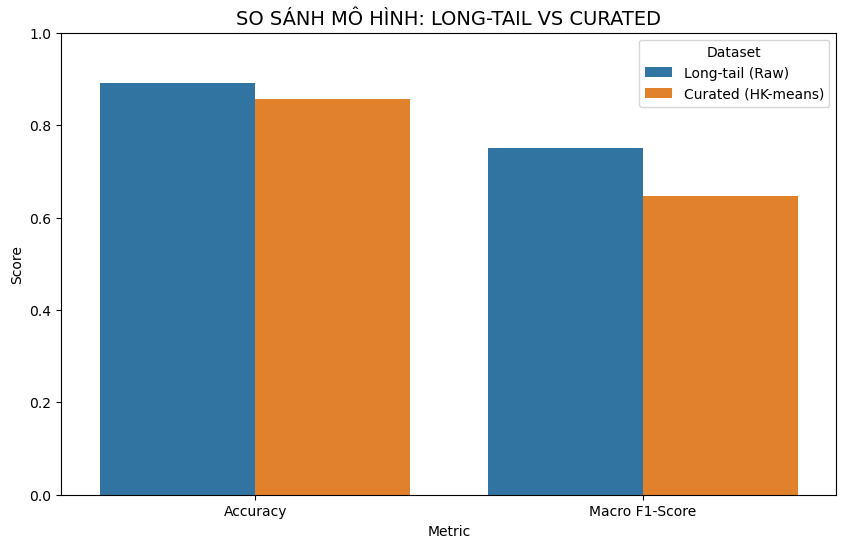

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
X_text_norm = normalize(X_features_text)

# 1. Chuẩn bị tập Test cân bằng để đánh giá công bằng
# Chúng ta lấy một phần dữ liệu gốc chưa bị làm Long-tail để làm tập Test chuẩn
X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X_text_norm, Y_lt_text, test_size=0.2, random_state=42, stratify=Y_lt_text
)

# 2. Lấy chỉ số của tập Curated (Case tốt nhất: T=3, m=10, k=[800, 500, 300])
# (Giả sử bạn đã chạy case này và có curated_idx_best)
# Nếu chưa có, ta chạy nhanh lại để lấy index:
best_centroids = hierarchical_kmeans_resampling(X_text_norm, [1000, 600, 400], 3, 10, num_init=1)
labels_best = KMeans(n_clusters=400, init=best_centroids, n_init=1).fit(X_text_norm).labels_

curated_idx_best = []
for i in range(400):
    idx_c = np.where(labels_best == i)[0]
    if len(idx_c) == 0: continue
    d = np.linalg.norm(X_text_norm[idx_c] - best_centroids[i], axis=1)
    curated_idx_best.extend(idx_c[np.argsort(d)[:min(len(idx_c), 6)]])

# 3. Huấn luyện Mô hình A: Toàn bộ tập Long-tail (Nhiều dữ liệu nhưng bị lệch)
print(f"Đang huấn luyện trên tập Long-tail (N={len(X_text_norm)})...")
model_lt = LogisticRegression(max_iter=1000)
model_lt.fit(X_text_norm, Y_lt_text)
pred_lt = model_lt.predict(X_test)

# 4. Huấn luyện Mô hình B: Tập Curated (Ít dữ liệu nhưng cân bằng)
print(f"Đang huấn luyện trên tập Curated (N={len(curated_idx_best)})...")
X_curated = X_text_norm[curated_idx_best]
Y_curated = Y_lt_text[curated_idx_best]
model_curated = LogisticRegression(max_iter=1000)
model_curated.fit(X_curated, Y_curated)
pred_curated = model_curated.predict(X_test)

# 5. TỔNG HỢP KẾT QUẢ
metrics = {
    "Metric": ["Accuracy", "Macro F1-Score", "Dung lượng tập huấn luyện"],
    "Long-tail (Raw)": [
        accuracy_score(Y_test, pred_lt),
        f1_score(Y_test, pred_lt, average='macro'),
        len(X_text_norm)
    ],
    "Curated (HK-means)": [
        accuracy_score(Y_test, pred_curated),
        f1_score(Y_test, pred_curated, average='macro'),
        len(curated_idx_best)
    ]
}

df_compare = pd.DataFrame(metrics)
print("\n--- BẢNG SO SÁNH HIỆU NĂNG ---")
print(df_compare)

# 6. Vẽ biểu đồ so sánh
df_plot = df_compare.melt(id_vars="Metric", var_name="Dataset", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot[df_plot['Metric'] != "Dung lượng tập huấn luyện"], 
            x='Metric', y='Score', hue='Dataset')
plt.title("SO SÁNH MÔ HÌNH: LONG-TAIL VS CURATED", fontsize=14)
plt.ylim(0, 1.0)
plt.show()